In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# تجهيز بيانات حقيقية لشركة وفروعها (بما فيهم فرع أسيوط اللي مقفل اللعبة!)
data = {
    'Branch': ['Assiut', 'Cairo', 'Alex', 'Assiut', 'Cairo', 'Alex', 'Assiut', 'Cairo'],
    'Sales': [45000, 35000, np.nan, 48000, np.nan, 22000, 50000, 38000],
    'Expenses': [12000, 15000, 10000, 11000, 14000, 9000, 13000, 16000],
    'Date': ['2026-01-01', '2026-01-01', '2026-01-02', '2026-01-02', '2026-01-03', '2026-01-03', '2026-01-04', '2026-01-04']
}

# تحويل البيانات لجدول بايثون (DataFrame)
df = pd.DataFrame(data)

# عرض أول 5 سطور عشان نتطمن على الداتا
df.head()

,Branch,Sales,Expenses,Date
0,Assiut,45000.0,12000,2026-01-01
1,Cairo,35000.0,15000,2026-01-01
2,Alex,NaN,10000,2026-01-02
3,Assiut,48000.0,11000,2026-01-02
4,Cairo,NaN,14000,2026-01-03


In [2]:
# 1. حساب متوسط المبيعات الحالي (بدون الفراغات)
sales_average = df['Sales'].mean()
print(f"متوسط مبيعات الفروع هو: {sales_average}")

# 2. استخدام دالة fillna لملا أي NaN بالمتوسط اللي حسبناه
df['Sales'] = df['Sales'].fillna(sales_average)

# 3. نعرض الجدول تاني عشان نتأكد إن الـ NaN اختفت
df

متوسط مبيعات الفروع هو: 39666.666666666664


,Branch,Sales,Expenses,Date
0,Assiut,45000.000000,12000,2026-01-01
1,Cairo,35000.000000,15000,2026-01-01
2,Alex,39666.666667,10000,2026-01-02
3,Assiut,48000.000000,11000,2026-01-02
4,Cairo,39666.666667,14000,2026-01-03
5,Alex,22000.000000,9000,2026-01-03
6,Assiut,50000.000000,13000,2026-01-04
7,Cairo,38000.000000,16000,2026-01-04


إجمالي المبيعات لكل فرع:
Branch
Alex       61666.666667
Assiut    143000.000000
Cairo     112666.666667
Name: Sales, dtype: float64
------------------------------


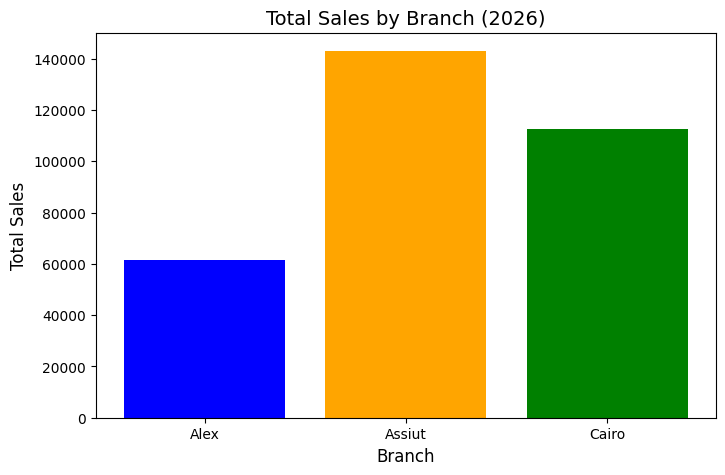

In [3]:
# 1. تجميع المبيعات لكل فرع (Group By) وحساب الإجمالي (Sum)
branch_sales = df.groupby('Branch')['Sales'].sum()
print("إجمالي المبيعات لكل فرع:")
print(branch_sales)
print("-" * 30)

# 2. رسم المبيعات باستخدام الرسم البياني بالأعمدة (Bar Chart)
plt.figure(figsize=(8, 5))
plt.bar(branch_sales.index, branch_sales.values, color=['blue', 'orange', 'green'])

# 3. تظبيط العناوين واللوحة للعميل
plt.title('Total Sales by Branch (2026)', fontsize=14)
plt.xlabel('Branch', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# 4. أظهر اللوحة يا بايثون!
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression

# 1. تحديد المدخلات (المصاريف) والمخرجات (المبيعات)
X = df[['Expenses']]  # المدخلات اللي الـ AI هيذاكرها
y = df['Sales']     # النتيجة الحقيقية

# 2. استدعاء الموديل وتدريبه (fit)
ai_model = LinearRegression()
ai_model.fit(X, y)

# 3. التنبؤ (predict): لو صرفنا 15000 على فرع جديد، مبيعاته المتوقعة هتبقى كام؟
future_sales = ai_model.predict([[15000]])

print(f"💰 التوقع الذكي للمبيعات لو صرفنا 15 ألف هو: {future_sales[0]:.2f}")

💰 التوقع الذكي للمبيعات لو صرفنا 15 ألف هو: 41710.32


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
# بعت الرقم جوه DataFrame بنفس اسم العمود عشان الـ AI يكون مبسوط وميطلعش تحذيرات
future_data = pd.DataFrame([[15000]], columns=['Expenses'])

# التنبؤ بدون أي تحذيرات
clean_prediction = ai_model.predict(future_data)

print(f"💰 التوقع الاحترافي للمبيعات هو: {clean_prediction[0]:.2f}")

💰 التوقع الاحترافي للمبيعات هو: 41710.32
